<a href="https://colab.research.google.com/github/enjoyyops/machine-learning-6/blob/main/machineLearningKlasifikasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

In [6]:
# Load data
wine = load_wine()
df = pd.DataFrame(data=np.c_[wine['data'], wine['target']],
                  columns=wine['feature_names'] + ['target'])

X = df.drop('target', axis=1)
y = df['target']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

=== KLASIFIKASI ===
Akurasi : 0.9444444444444444
Presisi : 0.9513888888888888
Recall  : 0.9444444444444444
F1 Score: 0.9448559670781892

               precision    recall  f1-score   support

         0.0       1.00      0.93      0.96        14
         1.0       0.88      1.00      0.93        14
         2.0       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



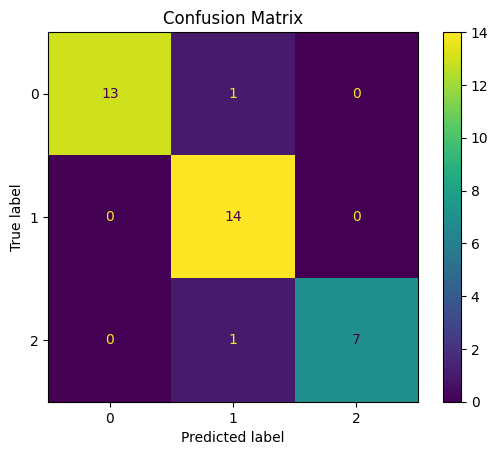

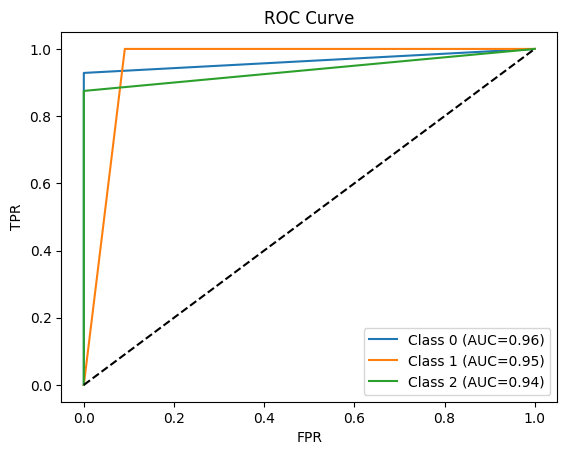

In [7]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# Evaluasi
print("=== KLASIFIKASI ===")
print("Akurasi :", accuracy_score(y_test, y_pred))
print("Presisi :", precision_score(y_test, y_pred, average='weighted'))
print("Recall  :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
y_test_bin = label_binarize(y_test, classes=np.unique(y))
y_score = clf.predict_proba(X_test)

for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC={roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()